# Stability of Various Models

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

# Lecture 6-4


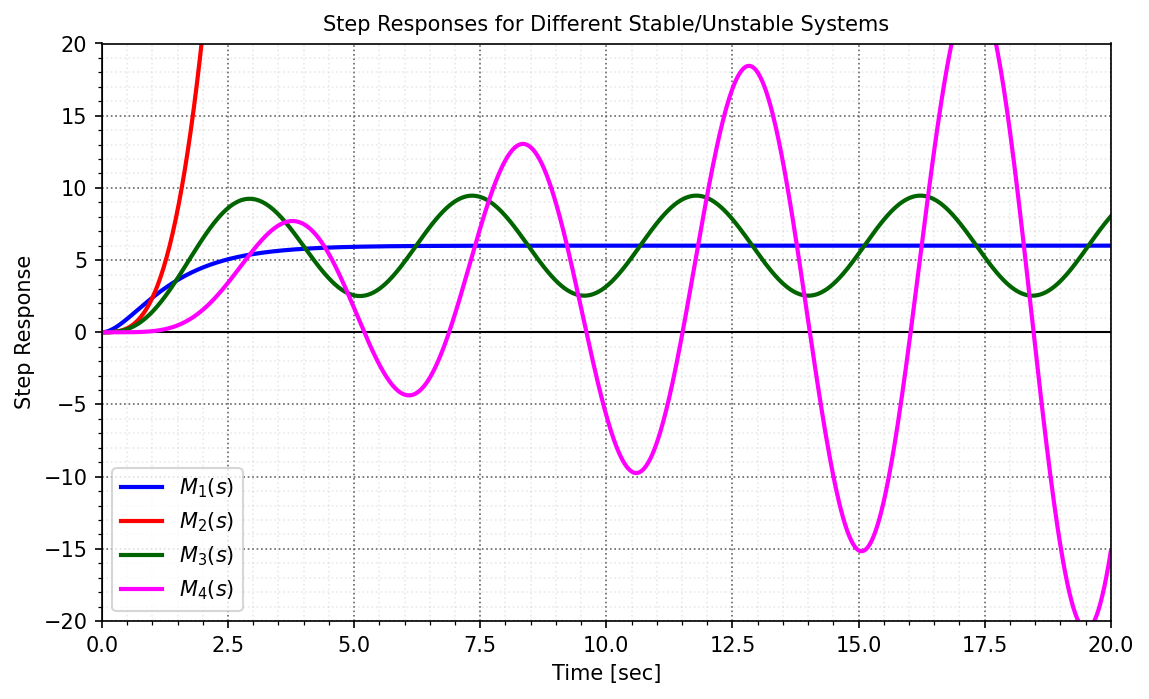

In [10]:
tt = np.linspace(0,20,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
bm.nicegrid(ax)

T0 = ct.tf((1), (1,1))
T1 = ct.tf((1), (1,2))
T2 = ct.tf((1), (1,0,2))
T3 = ct.tf((1), (1,-1))
G0 = 12*T1*T0
G1 = 12*T3*T2
G2 = 12*T0*T2
G3 = 12*T0*T2**2

systems = [G0, G1, G2, G3]
labels = [r'$M_1(s)$', r'$M_2(s)$', r'$M_3(s)$', r'$M_4(s)$']

for kk, (system, label) in enumerate(zip(systems, labels)):
    yy, tt = cmat.step(system, tt)
    ax.plot(tt, yy, label=label, color=colors[kk])

ax.legend()
ax.set_ylim((-20,20))
plt.title("Step Responses for Different Stable/Unstable Systems")
plt.savefig("./figs/Ex84.pdf", dpi=600)
plt.show()